In [83]:
import numpy as np
import pandas as pd

In [84]:
df=pd.read_csv('Heart_disease.csv')

In [85]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [86]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,0,145,233,1,2,150,0,2.3,2,0,2,0
1,67,1,3,160,286,0,2,108,1,1.5,1,3,1,1
2,67,1,3,120,229,0,2,129,1,2.6,1,2,3,1
3,37,1,2,130,250,0,0,187,0,3.5,2,0,1,0
4,41,0,1,130,204,0,2,172,0,1.4,0,0,1,0


In [89]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [90]:
print(df.duplicated().sum())

0


In [91]:
import matplotlib.pyplot as plt
import seaborn as sns

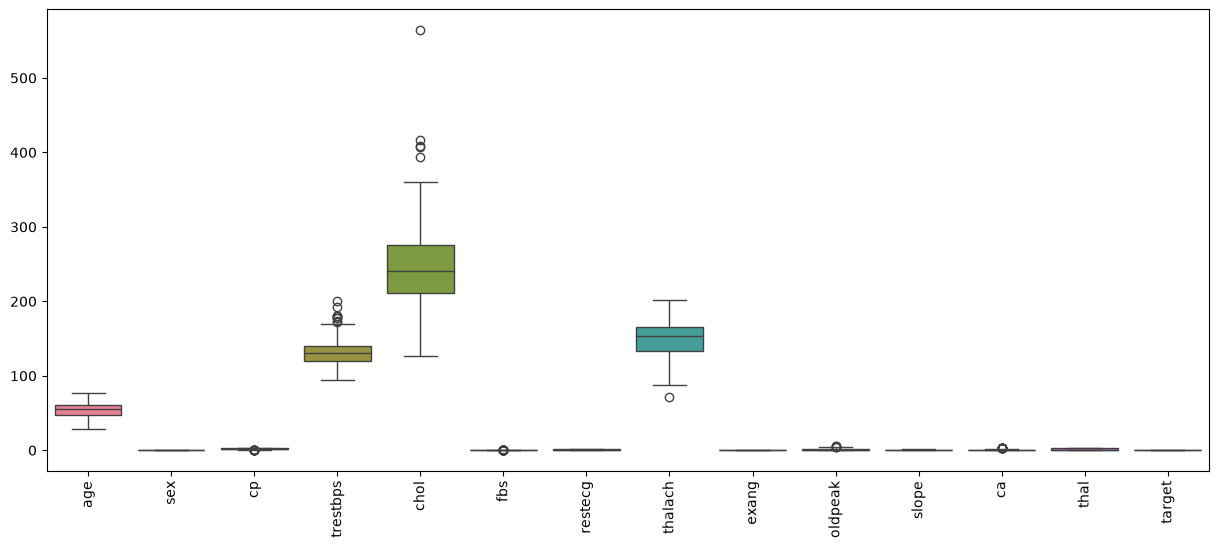

In [92]:
plt.figure(figsize=(15,6))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [93]:
X = df.drop("target",axis=1)

y = df["target"]

In [94]:
# Check Class Imbalance
y.value_counts()

target
0    164
1    139
Name: count, dtype: int64

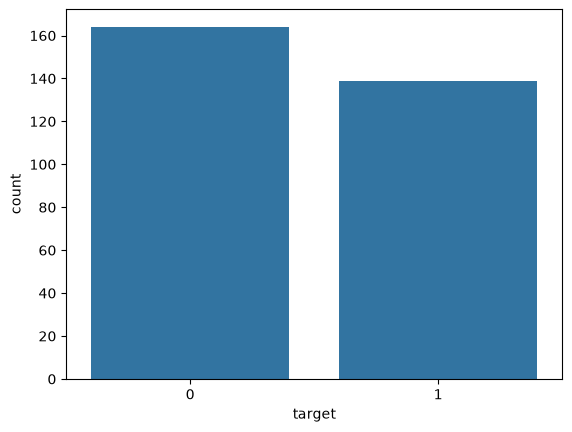

In [95]:
sns.countplot(x=y)
plt.show()

In [96]:
from imblearn.over_sampling import SMOTE

In [97]:
smote = SMOTE(random_state=42)

X_resampled, y_resampled = smote.fit_resample(X,y)

In [98]:
y_resampled.value_counts()

target
0    164
1    164
Name: count, dtype: int64

In [99]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report


In [100]:
#Train Test split
X_train,X_test,y_train,y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

In [101]:
# scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [102]:
def evaluate_model(model):

    y_pred = model.predict(X_test)

    print("Accuracy :",accuracy_score(y_test,y_pred))

    print("\nConfusion Matrix")

    print(confusion_matrix(y_test,y_pred))

    print("\nPrecision :",precision_score(y_test,y_pred))

    print("Recall :",recall_score(y_test,y_pred))

    print("F1 Score :",f1_score(y_test,y_pred))

    print("\nClassification Report")

    print(classification_report(y_test,y_pred))

Knn

In [103]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

In [104]:
knn = KNeighborsClassifier()

knn.fit(X_train,y_train)

evaluate_model(knn)

Accuracy : 0.7575757575757576

Confusion Matrix
[[19 11]
 [ 5 31]]

Precision : 0.7380952380952381
Recall : 0.8611111111111112
F1 Score : 0.7948717948717948

Classification Report
              precision    recall  f1-score   support

           0       0.79      0.63      0.70        30
           1       0.74      0.86      0.79        36

    accuracy                           0.76        66
   macro avg       0.76      0.75      0.75        66
weighted avg       0.76      0.76      0.75        66



Grid Serach cv -Knn

In [105]:
params = { 'n_neighbors':[3,5,7,9],'weights':['uniform','distance'],'metric':['euclidean','manhattan']}

grid_knn = GridSearchCV(
    KNeighborsClassifier(),
    params,
    cv=5,
    scoring='accuracy'
)

grid_knn.fit(X_train,y_train)

print(grid_knn.best_params_)
print(grid_knn.best_score_)

{'metric': 'euclidean', 'n_neighbors': 9, 'weights': 'distance'}
0.8435413642960812


In [137]:
print(grid_knn.best_estimator_)

KNeighborsClassifier(metric='euclidean', n_neighbors=9, weights='distance')


In [106]:
best_knn = grid_knn.best_estimator_

evaluate_model(best_knn)

Accuracy : 0.7424242424242424

Confusion Matrix
[[22  8]
 [ 9 27]]

Precision : 0.7714285714285715
Recall : 0.75
F1 Score : 0.7605633802816901

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        30
           1       0.77      0.75      0.76        36

    accuracy                           0.74        66
   macro avg       0.74      0.74      0.74        66
weighted avg       0.74      0.74      0.74        66



DecisionTree

In [107]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train,y_train)

evaluate_model(dt)

Accuracy : 0.7424242424242424

Confusion Matrix
[[22  8]
 [ 9 27]]

Precision : 0.7714285714285715
Recall : 0.75
F1 Score : 0.7605633802816901

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.73      0.72        30
           1       0.77      0.75      0.76        36

    accuracy                           0.74        66
   macro avg       0.74      0.74      0.74        66
weighted avg       0.74      0.74      0.74        66



Grid Search CV-decesion tree

In [108]:
params = {
    'criterion':['gini','entropy'],
    'max_depth':[3,5,7,10,None],
    'min_samples_split':[2,5,10]
}

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid_dt.fit(X_train,y_train)

print(grid_dt.best_params_)

{'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


In [109]:
best_dt = grid_dt.best_estimator_

evaluate_model(best_dt)

Accuracy : 0.7575757575757576

Confusion Matrix
[[26  4]
 [12 24]]

Precision : 0.8571428571428571
Recall : 0.6666666666666666
F1 Score : 0.75

Classification Report
              precision    recall  f1-score   support

           0       0.68      0.87      0.76        30
           1       0.86      0.67      0.75        36

    accuracy                           0.76        66
   macro avg       0.77      0.77      0.76        66
weighted avg       0.78      0.76      0.76        66



RandomForest

In [110]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train,y_train)

evaluate_model(rf)

Accuracy : 0.7424242424242424

Confusion Matrix
[[23  7]
 [10 26]]

Precision : 0.7878787878787878
Recall : 0.7222222222222222
F1 Score : 0.7536231884057971

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.77      0.73        30
           1       0.79      0.72      0.75        36

    accuracy                           0.74        66
   macro avg       0.74      0.74      0.74        66
weighted avg       0.75      0.74      0.74        66



Grid Serachcv-Random Forest

In [135]:
params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'criterion':['gini','entropy']
}

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42),
    params,
    cv=5,
    scoring='accuracy'
)

grid_rf.fit(X_train,y_train)

print(grid_rf.best_params_)

{'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 100}


In [136]:
best_rf = grid_rf.best_estimator_

evaluate_model(best_rf)

Accuracy : 0.7727272727272727

Confusion Matrix
[[26  4]
 [11 25]]

Precision : 0.8620689655172413
Recall : 0.6944444444444444
F1 Score : 0.7692307692307693

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.87      0.78        30
           1       0.86      0.69      0.77        36

    accuracy                           0.77        66
   macro avg       0.78      0.78      0.77        66
weighted avg       0.79      0.77      0.77        66



Logistic Regression

In [122]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train,y_train)

evaluate_model(lr)

Accuracy : 0.7727272727272727

Confusion Matrix
[[25  5]
 [10 26]]

Precision : 0.8387096774193549
Recall : 0.7222222222222222
F1 Score : 0.7761194029850746

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.83      0.77        30
           1       0.84      0.72      0.78        36

    accuracy                           0.77        66
   macro avg       0.78      0.78      0.77        66
weighted avg       0.78      0.77      0.77        66



GridSearchCV - Logistic Regression

In [123]:
params = {
    'C':[0.01,0.1,1,10],
    'solver':['liblinear','lbfgs']
}

grid_lr = GridSearchCV(
    LogisticRegression(max_iter=1000),
    params,
    cv=5,
    scoring='accuracy'
)

grid_lr.fit(X_train,y_train)

print(grid_lr.best_params_)

{'C': 0.01, 'solver': 'lbfgs'}


In [124]:
best_lr = grid_lr.best_estimator_

evaluate_model(best_lr)

Accuracy : 0.7727272727272727

Confusion Matrix
[[26  4]
 [11 25]]

Precision : 0.8620689655172413
Recall : 0.6944444444444444
F1 Score : 0.7692307692307693

Classification Report
              precision    recall  f1-score   support

           0       0.70      0.87      0.78        30
           1       0.86      0.69      0.77        36

    accuracy                           0.77        66
   macro avg       0.78      0.78      0.77        66
weighted avg       0.79      0.77      0.77        66



SVM

In [125]:
svm = SVC()

svm.fit(X_train,y_train)

evaluate_model(svm)

Accuracy : 0.7575757575757576

Confusion Matrix
[[24  6]
 [10 26]]

Precision : 0.8125
Recall : 0.7222222222222222
F1 Score : 0.7647058823529411

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.80      0.75        30
           1       0.81      0.72      0.76        36

    accuracy                           0.76        66
   macro avg       0.76      0.76      0.76        66
weighted avg       0.76      0.76      0.76        66



GridSearchCV - SVM

In [126]:
params = {
    'C':[0.1,1,10],
    'kernel':['linear','rbf'],
    'gamma':['scale','auto']
}

grid_svm = GridSearchCV(
    SVC(),
    params,
    cv=5,
    scoring='accuracy'
)

grid_svm.fit(X_train,y_train)

print(grid_svm.best_params_)

{'C': 10, 'gamma': 'scale', 'kernel': 'linear'}


In [127]:
best_svm = grid_svm.best_estimator_

evaluate_model(best_svm)

Accuracy : 0.7575757575757576

Confusion Matrix
[[24  6]
 [10 26]]

Precision : 0.8125
Recall : 0.7222222222222222
F1 Score : 0.7647058823529411

Classification Report
              precision    recall  f1-score   support

           0       0.71      0.80      0.75        30
           1       0.81      0.72      0.76        36

    accuracy                           0.76        66
   macro avg       0.76      0.76      0.76        66
weighted avg       0.76      0.76      0.76        66



compare all model

In [128]:
models = {
    "KNN":best_knn,
    "Decision Tree":best_dt,
    "Random Forest":best_rf,
    "Logistic Regression":best_lr,
    "SVM":best_svm
}

results=[]

for name,model in models.items():

    pred = model.predict(X_test)

    results.append([
        name,
        accuracy_score(y_test,pred),
        precision_score(y_test,pred),
        recall_score(y_test,pred),
        f1_score(y_test,pred)
    ])

result_df = pd.DataFrame(
    results,
    columns=["Model","Accuracy","Precision","Recall","F1 Score"]
)
print(result_df)


                 Model  Accuracy  Precision    Recall  F1 Score
0                  KNN  0.742424   0.771429  0.750000  0.760563
1        Decision Tree  0.757576   0.857143  0.666667  0.750000
2        Random Forest  0.772727   0.862069  0.694444  0.769231
3  Logistic Regression  0.772727   0.862069  0.694444  0.769231
4                  SVM  0.757576   0.812500  0.722222  0.764706
